In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

In [58]:
#Load the dataset
df=pd.read_csv("synthetic_dataset.csv")
df

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...,...
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0


In [5]:
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [7]:
df.tail()

,Category,Price,Rating,Stock,Discount
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0
4361,NaN,NaN,2.184471,NaN,0.0


In [9]:
#Shape Rows and Columns
df.shape


(4362, 5)

## Data Types

In [12]:
df.dtypes

Category     object
Price       float64
Rating      float64
Stock        object
Discount    float64
dtype: object

In [83]:
## Basic Summary Statitics
df.describe()


,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


In [19]:
#Numerical Columns
numerical_col=df.select_dtypes(include=['int64','float64']).columns
#Categorical columns
categorical_col=df.select_dtypes(include=['object']).columns
print("Numerical Columns:",numerical_col)
print("Categorical Columns:",categorical_col)

Numerical Columns: Index(['Price', 'Rating', 'Discount'], dtype='object')
Categorical Columns: Index(['Category', 'Stock'], dtype='object')


## Task-2 ->Missing Value Audit

In [20]:
missing_count=df.isnull().sum()
print(missing_count)

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


In [21]:
## Missing values Percentage
missing_percentage=(df.isnull().sum()/len(df))*100 
print(missing_percentage)

Category    62.998624
Price        3.988996
Rating      46.996790
Stock       30.994956
Discount     8.986703
dtype: float64


In [22]:
## Create a Missing Value Table
missing_table=pd.DataFrame({
    "Missing_Count":df.isnull().sum(),
    "Missing_Percentage":(df.isnull().sum()/len(df))*100
})
missing_table=missing_table.sort_values(by="Missing_Percentage",ascending=False)



In [23]:
missing_table

,Missing_Count,Missing_Percentage
Category,2748,62.998624
Rating,2050,46.996790
Stock,1352,30.994956
Discount,392,8.986703
Price,174,3.988996


## Task 3:Visualize the missing Data

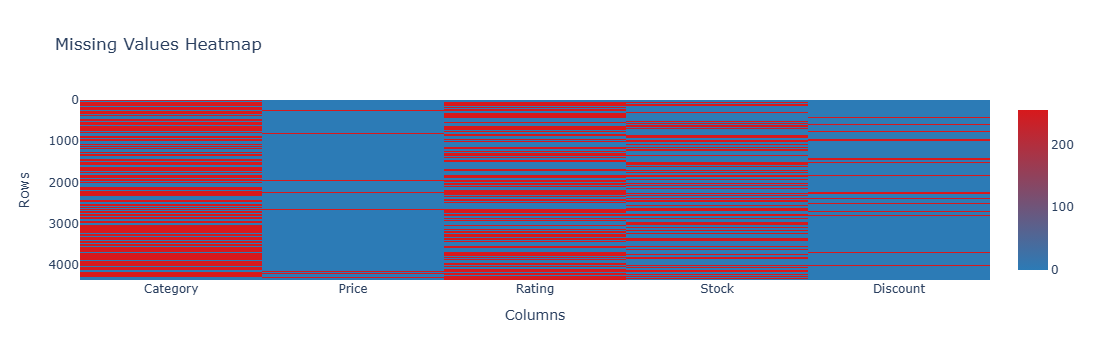

In [24]:
missing_data=df.isnull()
fig=px.imshow(
    missing_data,
    aspect="auto",
    color_continuous_scale=["#2c7bb6","#d7191c"],
    title="Missing Values Heatmap")
fig.update_layout(
    xaxis_title="Columns",
    yaxis_title="Rows")
fig.show()

In [38]:
## Bar Chart for missing percentage
missing_df=(df.isnull().sum()/len(df))*100
missing_df=missing_percentage.reset_index()
missing_df.columns=["Columns","Missing_Percentage"]
missing_df=missing_df.sort_values(by="Missing_Percentage",ascending=False)
missing_df

,Columns,Missing_Percentage
0,Category,62.998624
2,Rating,46.996790
3,Stock,30.994956
4,Discount,8.986703
1,Price,3.988996


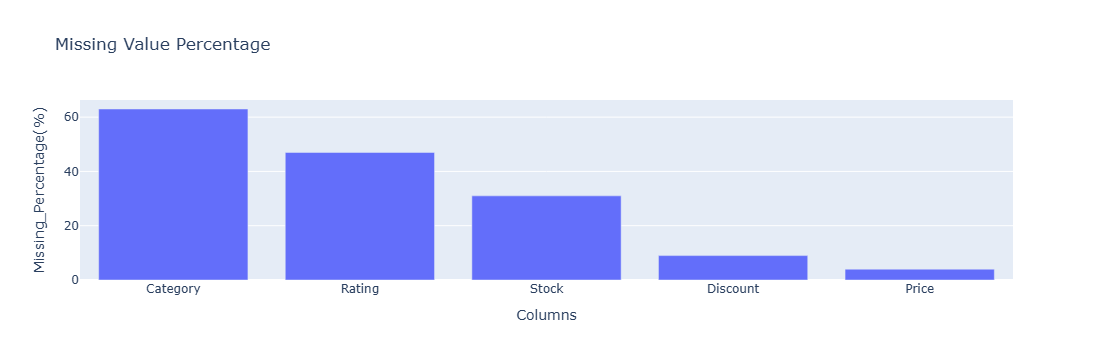

In [39]:
fig=go.Figure()
fig.add_bar(
    x=missing_df["Columns"],
    y=missing_df["Missing_Percentage"])
fig.update_layout(
    title="Missing Value Percentage",
    xaxis_title="Columns",
    yaxis_title="Missing_Percentage(%)")
fig.show()

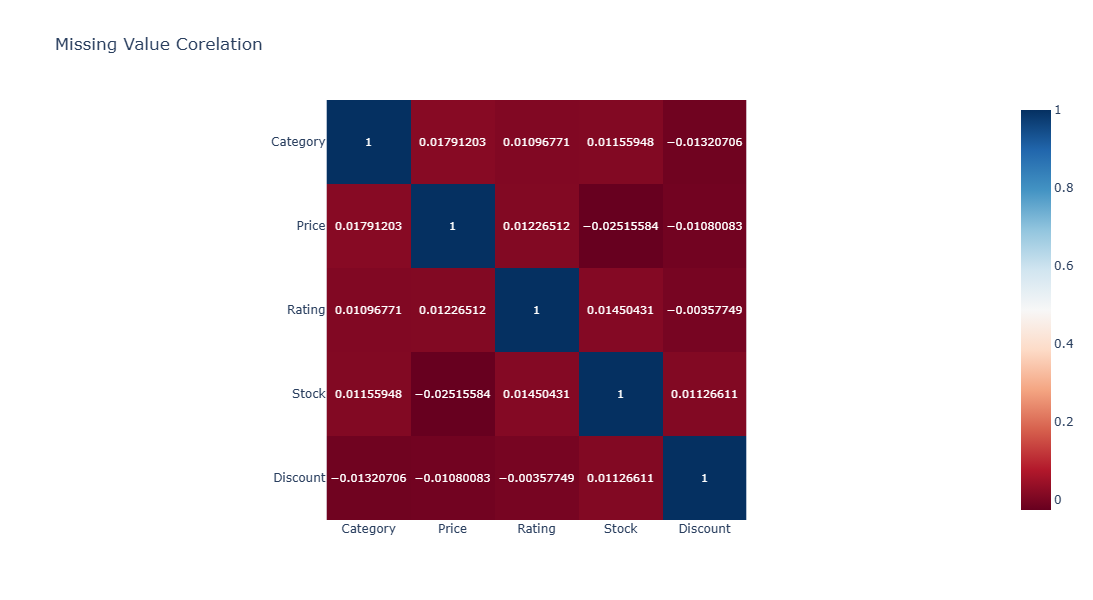

In [82]:
missing_corr=df.isnull().corr()
fig=px.imshow(
    missing_corr,
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Missing Value Corelation")
fig.update_layout(
    width=1000,
    height=600)
fig.show()

## Drop High-Missing Columns

In [57]:
threshold=0.60
#df["Category"].fillna("Unknown", inplace=True)

In [49]:
missing_percentage=df.isnull().mean()
missing_percentage

Category    0.629986
Price       0.039890
Rating      0.469968
Stock       0.309950
Discount    0.089867
dtype: float64

In [53]:
cols_to_drop=missing_percentage[missing_percentage>threshold].index
print(cols_to_drop)

Index(['Category'], dtype='object')


In [56]:
df=df.drop(columns=cols_to_drop)
df


,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,NaN,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...
4357,4436.0,4.728335,NaN,49.0
4358,6236.0,NaN,Out of Stock,4.0
4359,3283.0,NaN,Out of Stock,9.0
4360,2999.0,4.425995,NaN,40.0


## Row Level Missing Analysis

In [59]:
df

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...,...
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0


In [60]:
df["missing_count"]=df.isnull().sum(axis=1)


In [61]:
df.head()

,Category,Price,Rating,Stock,Discount,missing_count
0,NaN,5548.0,1.870322,NaN,0.0,2
1,NaN,3045.0,4.757798,NaN,38.0,2
2,NaN,4004.0,NaN,In Stock,0.0,2
3,NaN,4808.0,1.492085,NaN,33.0,2
4,NaN,1817.0,NaN,Out of Stock,23.0,2


In [62]:
df.tail()

,Category,Price,Rating,Stock,Discount,missing_count
4357,NaN,4436.0,4.728335,NaN,49.0,2
4358,B,6236.0,NaN,Out of Stock,4.0,1
4359,NaN,3283.0,NaN,Out of Stock,9.0,2
4360,D,2999.0,4.425995,NaN,40.0,1
4361,NaN,NaN,2.184471,NaN,0.0,3


In [63]:
df_cleaned=df[df["missing_count"]<=3]
df_cleaned=df_cleaned.drop(columns=["missing_count"])
print(df.shape)
print(df_cleaned.shape)

(4362, 6)
(4306, 5)


## Numerical Imputation

In [66]:
df=pd.read_csv("synthetic_dataset.csv")
num_cols=df.select_dtypes(include=["int64","float64"]).columns
print(num_cols)

Index(['Price', 'Rating', 'Discount'], dtype='object')


In [69]:
df_mean=df.copy()
df_mean[num_cols]=df_mean[num_cols].fillna(df_mean[num_cols].mean())

In [70]:
df_mean.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,3.038293,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,3.038293,Out of Stock,23.0


In [74]:

df_median=df.copy()
df_median[num_cols]=df_median[num_cols].fillna(df_median[num_cols].median())

In [75]:
df_median.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,3.082060,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,3.082060,Out of Stock,23.0


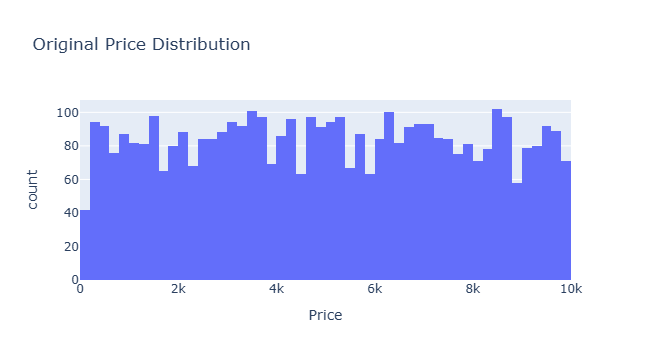

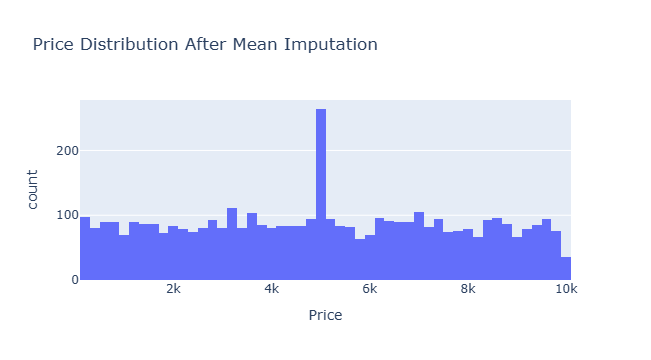

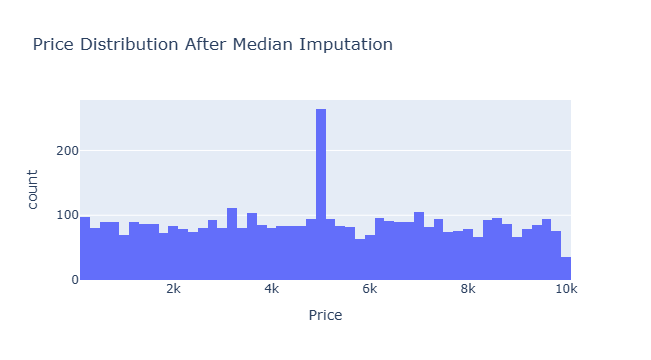

In [78]:
import plotly.express as px

fig = px.histogram(df, x="Price", title="Original Price Distribution")
fig.show()

fig = px.histogram(df_mean, x="Price", title="Price Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Price", title="Price Distribution After Median Imputation")
fig.show()

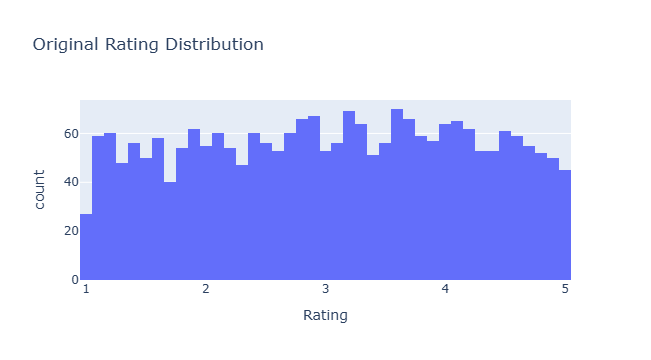

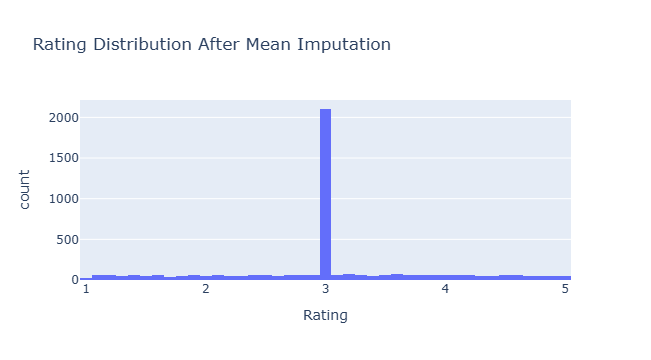

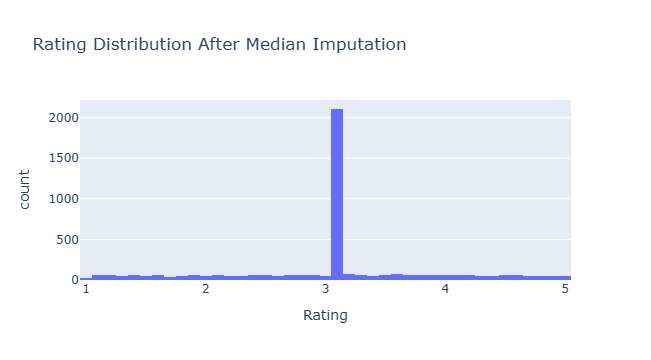

In [79]:
fig = px.histogram(df, x="Rating", title="Original Rating Distribution")
fig.show()

fig = px.histogram(df_mean, x="Rating", title="Rating Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Rating", title="Rating Distribution After Median Imputation")
fig.show()

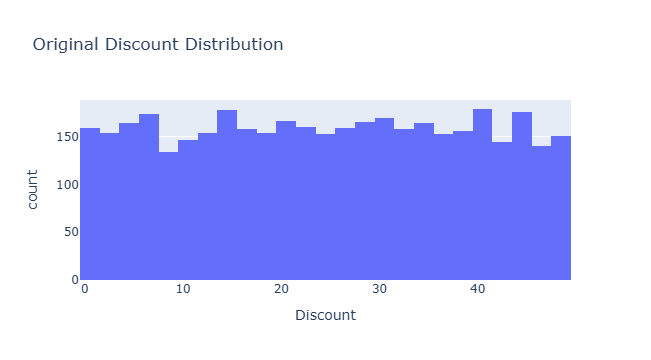

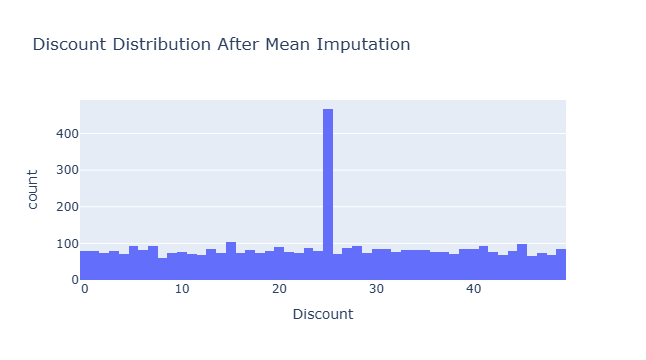

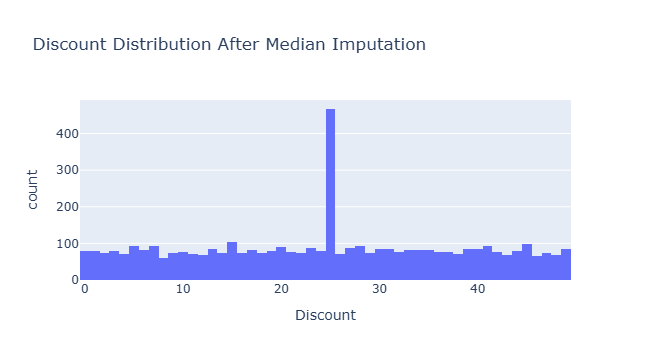

In [81]:
fig = px.histogram(df, x="Discount", title="Original Discount Distribution")
fig.show()

fig = px.histogram(df_mean, x="Discount", title="Discount Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Discount", title="Discount Distribution After Median Imputation")
fig.show()